---
title: "How Economic Development Reshapes Health Risk Across the Life Cycle"
subtitle: "How two distinct risk indicators evolve with economic development"
date: "2026-04-10"
author: "Sabrina Vitali"

format:
  html:
    theme: flatly
    embed-resources: true
    code-fold: true
    toc: true
    toc-depth: 2
    number-sections: true

fontsize: 1.1em
linestretch: 1.7

execute:
  echo: false
  warning: false
  message: false
---

## Introduction

This report explores how countries undergo <span style="color:#8c5a2b; font-weight:bold;">economic development</span> and how the <span style="color:#8b1e1e; font-weight:bold;">dominant health risk</span> shifts across the life course.

The distribution of health risk across different stages of life changes with the level of <span style="color:#8c5a2b; font-weight:bold;">development</span>.

The analysis highlights how development reshapes when and why risk occurs, from the <span style="color:#8b1e1e; font-weight:bold;">neonatal</span> period to <span style="color:#1f3c88; font-weight:bold;">adolescence</span>.

The report takes into consideration two key dimensions:

1. <span style="color:#8b1e1e; font-weight:bold;">EARLY-LIFE RISK</span>, proxied by <span style="color:#8b1e1e; font-weight:bold;">neonatal mortality</span>  
2. <span style="color:#1f3c88; font-weight:bold;">BEHAVIOURAL RISK</span>, associated with <span style="color:#1f3c88; font-weight:bold;">alcohol consumption</span>

Using UNICEF indicators and contextual metadata, the report asks a broader question: *does <span style="color:#8c5a2b; font-weight:bold;">development</span> reduce health risk, or does it transform it?*

It is evident that the two indicators do not capture the same type of risk. At first glance, early-life risk appears directly linked to mortality, while behavioural risk may seem less immediate and therefore less comparable.
However, this analysis shows that the difference is not in magnitude, but in **nature**: the two indicators reflect distinct dimensions of risk that emerge at different stages of the life cycle.

<span style="color:#8c5a2b; font-weight:bold;">GDP</span> is used as a proxy for <span style="color:#8c5a2b; font-weight:bold;">development</span> to understand how <span style="color:#8c5a2b; font-weight:bold;">economic growth</span> influences health risks across the life course.

The analysis focuses mostly on 2016 as a snapshot year to compare how health risks are distributed across different levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span>.

## Data Preparation

Before building the visualisations, the datasets were carefully cleaned and aligned to ensure consistency across indicators, countries, time.

The preparation process involved several key steps:

- **Selection of relevant variables**, focusing only on the indicators required for the analysis  
- **Renaming and standardisation** of variables to improve clarity and comparability across datasets  
- **Integration of the two indicators** into a unified analytical structure  
- **Merging with <span style="color:#8c5a2b; font-weight:bold;">GDP</span>-related classifications**, allowing each observation to be linked to a level of <span style="color:#8c5a2b; font-weight:bold;">economic development</span>  

This process was essential to ensure that all visualisations are based on a coherent and reproducible data structure.

It also enables a consistent comparison between the two indicators, both individually in relation to <span style="color:#8c5a2b; font-weight:bold;">GDP</span> and jointly to better understand how the structure of risk evolves with <span style="color:#8c5a2b; font-weight:bold;">economic development</span>.

In [64]:
#| include: false
#| code-summary: "Show setup and data loading code"

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Import Polars
import polars as pl

# Load datasets
unicef_indicator_1 = pl.read_csv("/content/drive/MyDrive/unicef_indicator_1.csv")
unicef_indicator_2 = pl.read_csv("/content/drive/MyDrive/unicef_indicator_2.csv")
unicef_metadata = pl.read_csv("/content/drive/MyDrive/unicef_metadata.csv")

# Quick structure check (safe for development, hidden in report)
unicef_indicator_1.head()
unicef_indicator_2.head()
unicef_metadata.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


country,alpha_2_code,alpha_3_code,numeric_code,year,"Population, total",GDP per capita (constant 2015 US$),GNI (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Military expenditure (% of GDP),Fossil fuel energy consumption (% of total),GDP growth (annual %),"Birth rate, crude (per 1,000 people)","Hospital beds (per 1,000 people)"
str,str,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""","""AF""","""AFG""",4,1960,9035043,null,5.4889e8,null,32.799,null,null,null,50.516,0.170627
"""Afghanistan""","""AF""","""AFG""",4,1961,9214083,null,5.6000e8,null,33.291,null,null,null,50.566,null
"""Afghanistan""","""AF""","""AFG""",4,1962,9404406,null,5.5778e8,null,33.757,null,null,null,50.666,null
"""Afghanistan""","""AF""","""AFG""",4,1963,9604487,null,7.6667e8,null,34.201,null,null,null,50.787,null
"""Afghanistan""","""AF""","""AFG""",4,1964,9814318,null,8.1556e8,null,34.673,null,null,null,50.852,null


In [65]:
#| code-summary: "Show setup and data loading code"
#| echo: false
#| message: false
#| warning: false
#| include: false

# CHECK DATASET DIMENSIONS TO UNDERSTAND DATA COVERAGE
print("Indicator 1 shape:", unicef_indicator_1.shape)
print("Indicator 2 shape:", unicef_indicator_2.shape)
print("Metadata shape:", unicef_metadata.shape)

Indicator 1 shape: (6742, 14)
Indicator 2 shape: (567, 14)
Metadata shape: (13715, 15)


In [66]:
#| include: false
# KEEP ONLY THE VARIABLES NEEDED FOR THE ANALYSIS

indicator_1_clean = unicef_indicator_1.select([
    "country", "alpha_3_code", "indicator", "time_period", "obs_value", "sex"
])

indicator_2_clean = unicef_indicator_2.select([
    "country", "alpha_3_code", "indicator", "time_period", "obs_value", "sex"
])

metadata_clean = unicef_metadata.select([
    "country", "alpha_3_code", "year",
    "Population, total",
    "GDP per capita (constant 2015 US$)",
    "Life expectancy at birth, total (years)"
])



In [67]:
#| include: false
# Rename variables to simplify interpretation and ensure consistency

indicator_1_clean = indicator_1_clean.rename({
    "time_period": "year"
})

indicator_2_clean = indicator_2_clean.rename({
    "time_period": "year"
})

metadata_clean = metadata_clean.rename({
    "Population, total": "TOTAL POPULATION",
    "GDP per capita (constant 2015 US$)": "GDP per capita",
    "Life expectancy at birth, total (years)": "LIFE EXPECTANCY AT BIRTH"
})

In [68]:
#| code-summary: "Show setup and data loading code"
#| echo: false
#| message: false
#| warning: false
#| include: false
# Standardize indicator names (make them short and readable)

indicator_1_clean = indicator_1_clean.with_columns(
    pl.lit("EARLY-LIFE RISK").alias("indicator")
)

indicator_2_clean = indicator_2_clean.with_columns(
    pl.lit("BEHAVIOURAL RISK").alias("indicator"))

In [69]:
data = pl.concat([indicator_1_clean, indicator_2_clean])

data = data.join(
    metadata_clean,
    on=["country", "alpha_3_code", "year"],
    how="left"
)

In [70]:
#| include: false

import polars as pl
import geopandas as gp
from plotnine import *

# Read UNICEF indicator 1
unicef_indicator_1 = pl.read_csv("/content/drive/MyDrive/unicef_indicator_1.csv")

# Keep only the columns needed for the map
map_data = unicef_indicator_1.select([
    "country",
    "alpha_3_code",
    "indicator",
    "time_period",
    "obs_value",
    "sex"
])

# Keep total sex only
map_data = map_data.filter(pl.col("sex") == "Total")

# Keep only the neonatal / early-life risk indicator
map_data = map_data.filter(
    pl.col("indicator").str.contains("Neonatal")
)

# Keep one year only
map_data = map_data.filter(pl.col("time_period") == 2016)

# Keep only final fields needed for the merge
map_data = map_data.select([
    "country",
    "alpha_3_code",
    "obs_value"
])

# Convert only at the final merge step
map_df = map_data.to_pandas()

# Read world shapefile
world = gp.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

# Merge by 3-letter country code
world_data = world.merge(
    map_df,
    left_on="SOV_A3",
    right_on="alpha_3_code",
    how="left"
)

### A global perspective on early-life risk

The two maps provide a snapshot of how <span style="color:#8b1e1e; font-weight:bold;">early-life risk</span> is distributed across countries in 2016 and 2023.

At first glance, the pattern may appear counterintuitive: countries with higher levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span> often show a greater relative contribution of <span style="color:#8b1e1e; font-weight:bold;">neonatal mortality</span> (within the first 28 days of life) to total under-five mortality.

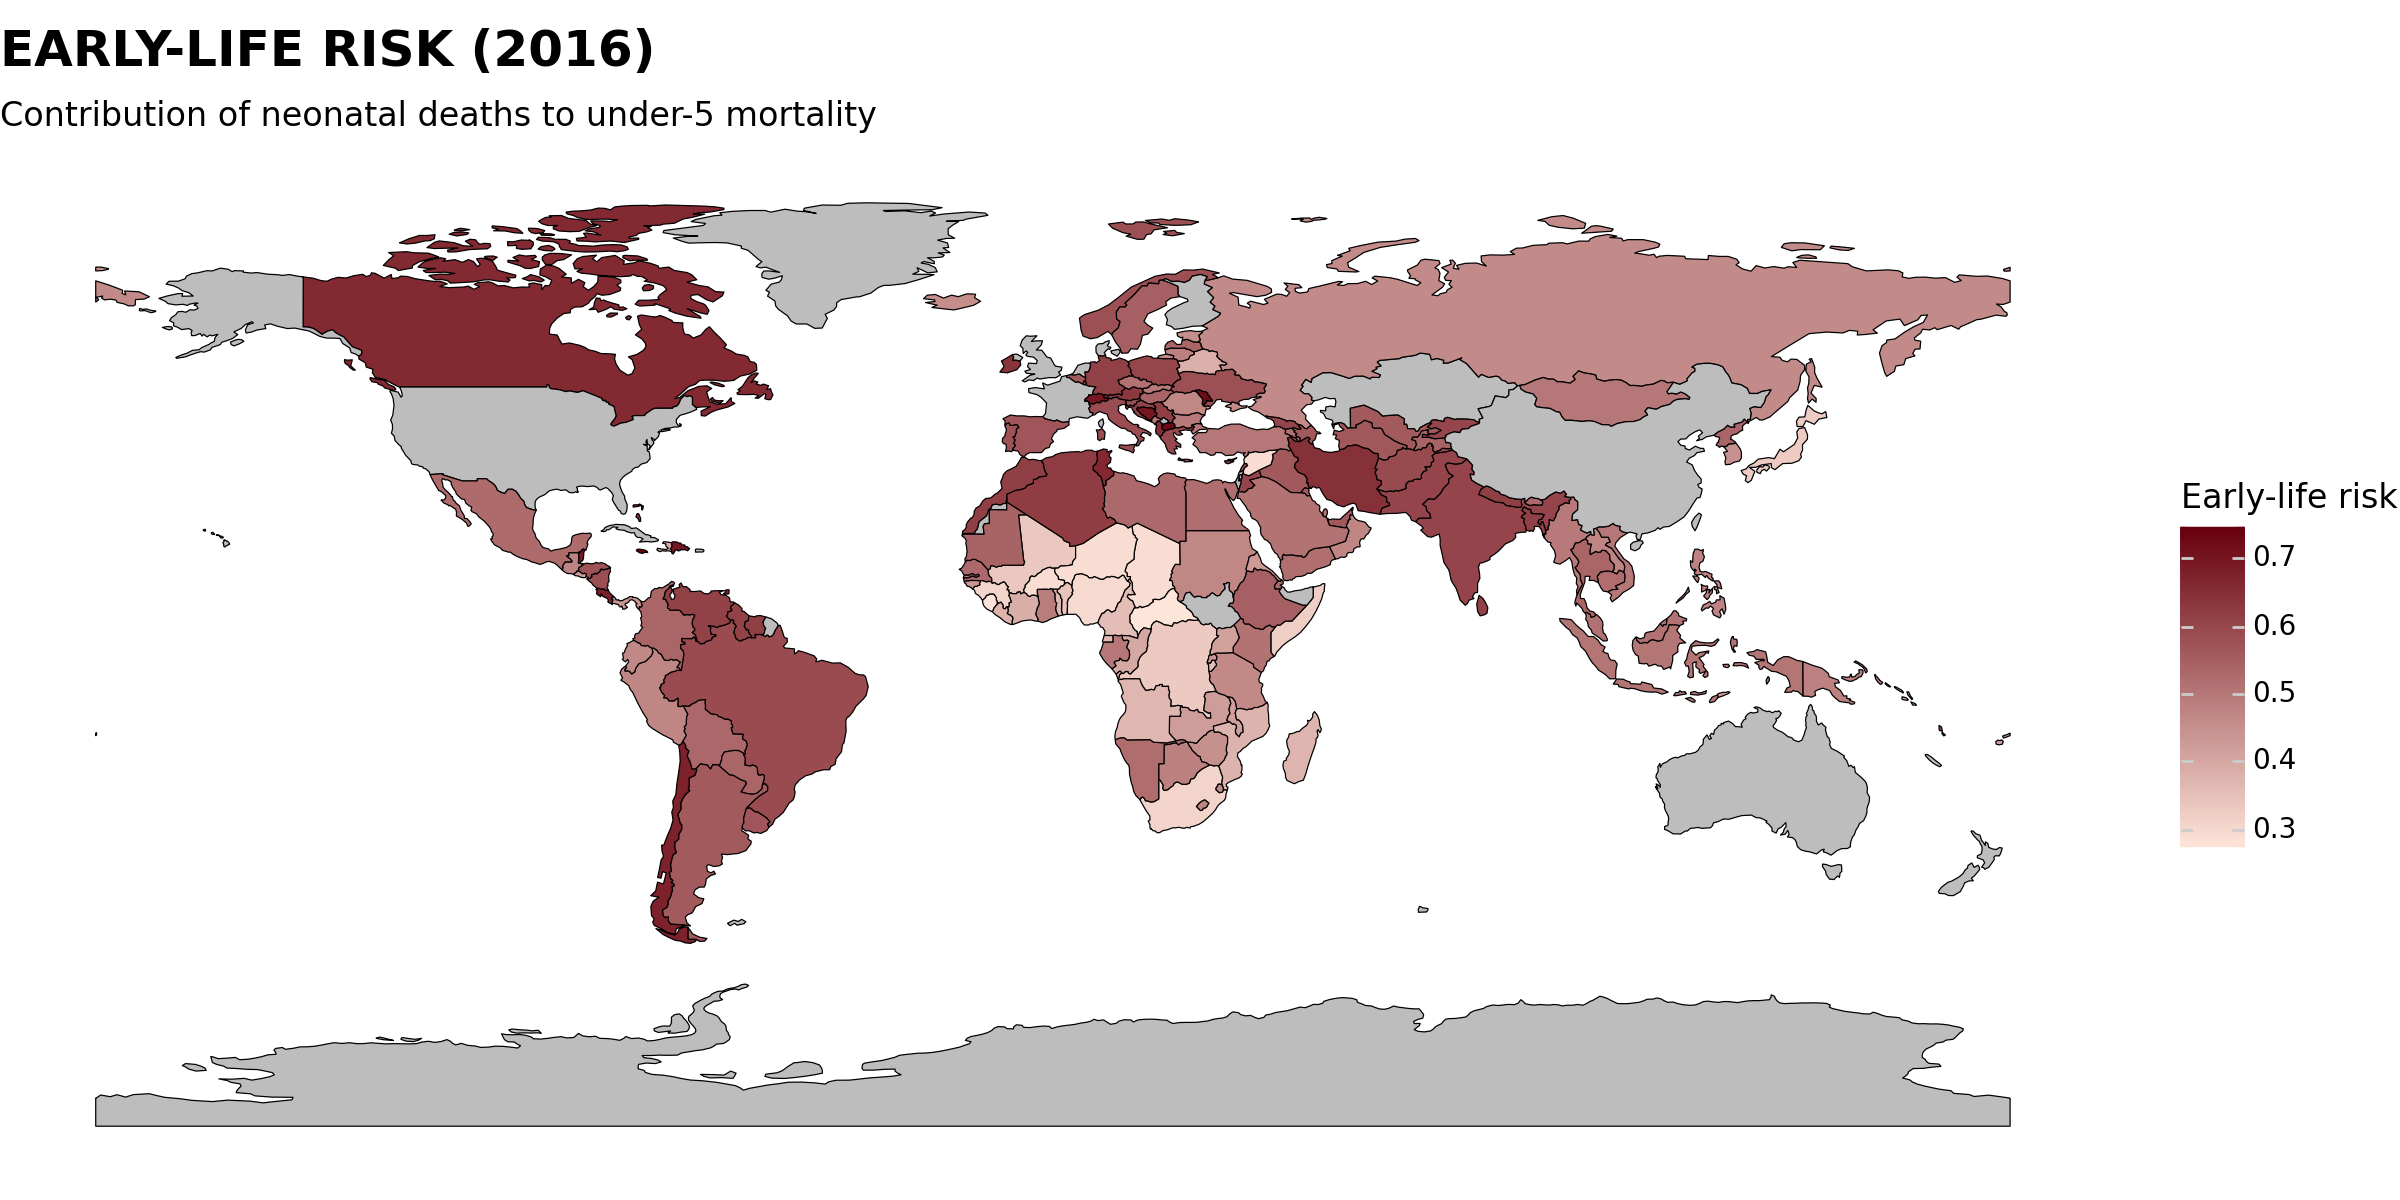

In [71]:
#| echo: false
#| warning: false
#| message: false
#| fig-cap: "Geography of early-life risk in 2016."

(
    ggplot(world_data)
    + geom_map(
        aes(fill="obs_value", map_id="SOV_A3"),
        color="black",
        size=0.25
    )
    + coord_fixed()
    + labs(
        title="EARLY-LIFE RISK (2016)",
        subtitle="Contribution of neonatal deaths to under-5 mortality",
        fill="Early-life risk"
    )
    + scale_fill_gradient(
        low="#fee5d9",
        high="#67000d",
        na_value="#bdbdbd"
    )
    + theme_void()
    + theme(
        figure_size=(12, 6),
        plot_title=element_text(size=18, weight="bold"),
        plot_subtitle=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10)
    )
)



*   lighter red represents a lower rate of Neonatal Mortality within the first 28 days
*   darker red represents an higher rate of Neonatal Mortality within the first 28 days



In [72]:
#| include: false

import polars as pl
import geopandas as gp
from plotnine import *

# Read UNICEF indicator 1
unicef_indicator_1 = pl.read_csv("/content/drive/MyDrive/unicef_indicator_1.csv")

# Keep only the columns needed for the map
map_data = unicef_indicator_1.select([
    "country",
    "alpha_3_code",
    "indicator",
    "time_period",
    "obs_value",
    "sex"
])

# Ensure year is numeric
map_data = map_data.with_columns(
    pl.col("time_period").cast(pl.Int64, strict=False)
)

# Keep total sex only
map_data = map_data.filter(pl.col("sex") == "Total")

# Keep only the neonatal / early-life risk indicator
map_data = map_data.filter(
    pl.col("indicator").str.contains("Neonatal")
)

# Keep one year only
map_data = map_data.filter(pl.col("time_period") == 2023)

# Keep only final fields needed for the merge
map_data = map_data.select([
    "country",
    "alpha_3_code",
    "obs_value"
])

# Convert only at the final merge step
map_df = map_data.to_pandas()

# Read world shapefile
world = gp.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

# Merge by 3-letter country code
world_data = world.merge(
    map_df,
    left_on="SOV_A3",
    right_on="alpha_3_code",
    how="left"
)

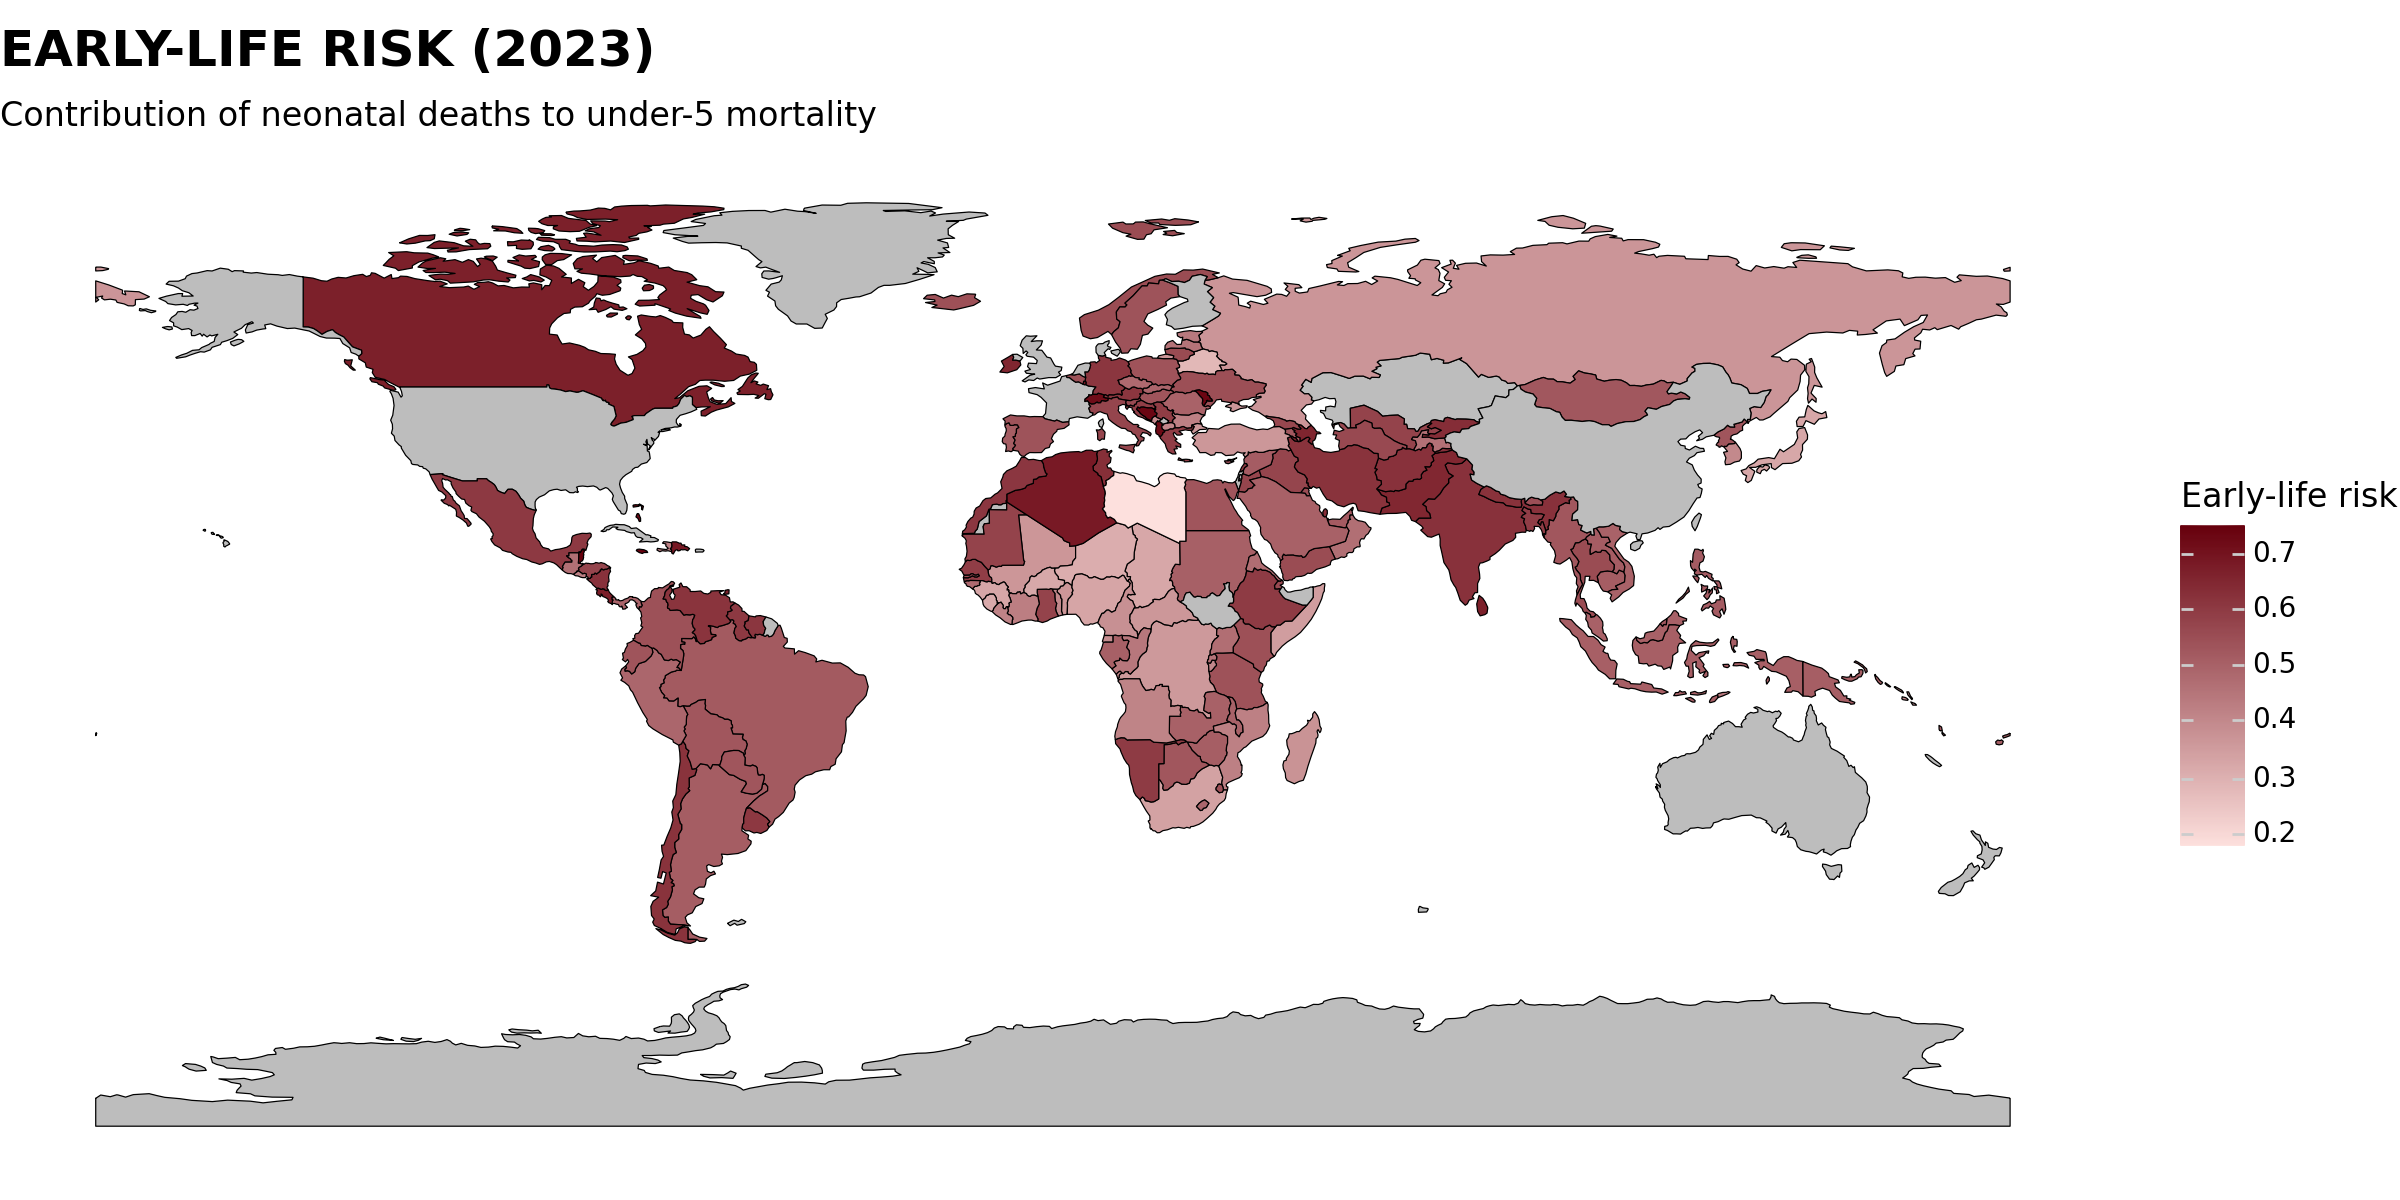

In [73]:
#| echo: false
#| warning: false
#| message: false
#| fig-cap: "Geography of early-life risk in 2023."

(
    ggplot(world_data)
    + geom_map(
        aes(fill="obs_value", map_id="SOV_A3"),
        color="black",
        size=0.25
    )
    + coord_fixed()
    + labs(
        title="EARLY-LIFE RISK (2023)",
        subtitle="Contribution of neonatal deaths to under-5 mortality",
        fill="Early-life risk"
    )
    + scale_fill_gradient(
        low="#fde0dd",
        high="#67000d",
        na_value="#bdbdbd"
    )
    + theme_void()
    + theme(
        figure_size=(12, 6),
        plot_title=element_text(size=18, weight="bold"),
        plot_subtitle=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10)
    )
)

Seven years later, the overall pattern remains consistent, although the intensity of the red tones is more pronounced, reflecting a higher concentration of neonatal mortality within the first 28 days of life.

### Why does early-life risk increase with development?

This does not imply that countries with higher levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span> face worse health conditions. Instead, it reflects a structural transformation in the causes of mortality.

In low-income settings, deaths are more likely to occur after the <span style="color:#8b1e1e; font-weight:bold;">neonatal</span> period, often driven by preventable conditions such as infections, malnutrition and limited access to healthcare.

As countries undergo <span style="color:#8c5a2b; font-weight:bold;">economic development</span>, these causes decline significantly. What remains is a higher concentration of deaths in the <span style="color:#8b1e1e; font-weight:bold;">neonatal</span> phase, which is more closely linked to biological factors and the quality of advanced medical care.

In this sense, a higher share of <span style="color:#8b1e1e; font-weight:bold;">early-life risk</span> becomes an indirect signal of stronger health systems and higher levels of <span style="color:#8c5a2b; font-weight:bold;">economic development</span>.

In [74]:
#| echo: false
#| warning: false
#| message: false
#| include: false

import polars as pl
!pip install gapminder
from gapminder import gapminder

# Convert gapminder to Polars in a safe way
gap_time_data = (
    pl.from_dicts(gapminder.to_dict(orient="records"))
    .select(["year", "continent", "lifeExp"])
    .with_columns([
        pl.col("year").cast(pl.Int64, strict=False),
        pl.col("lifeExp").cast(pl.Float64, strict=False),
        pl.col("continent").cast(pl.Utf8)
    ])
    .group_by(["year", "continent"])
    .agg(
        pl.mean("lifeExp").alias("avg_lifeExp")
    )
    .sort(["continent", "year"])
)

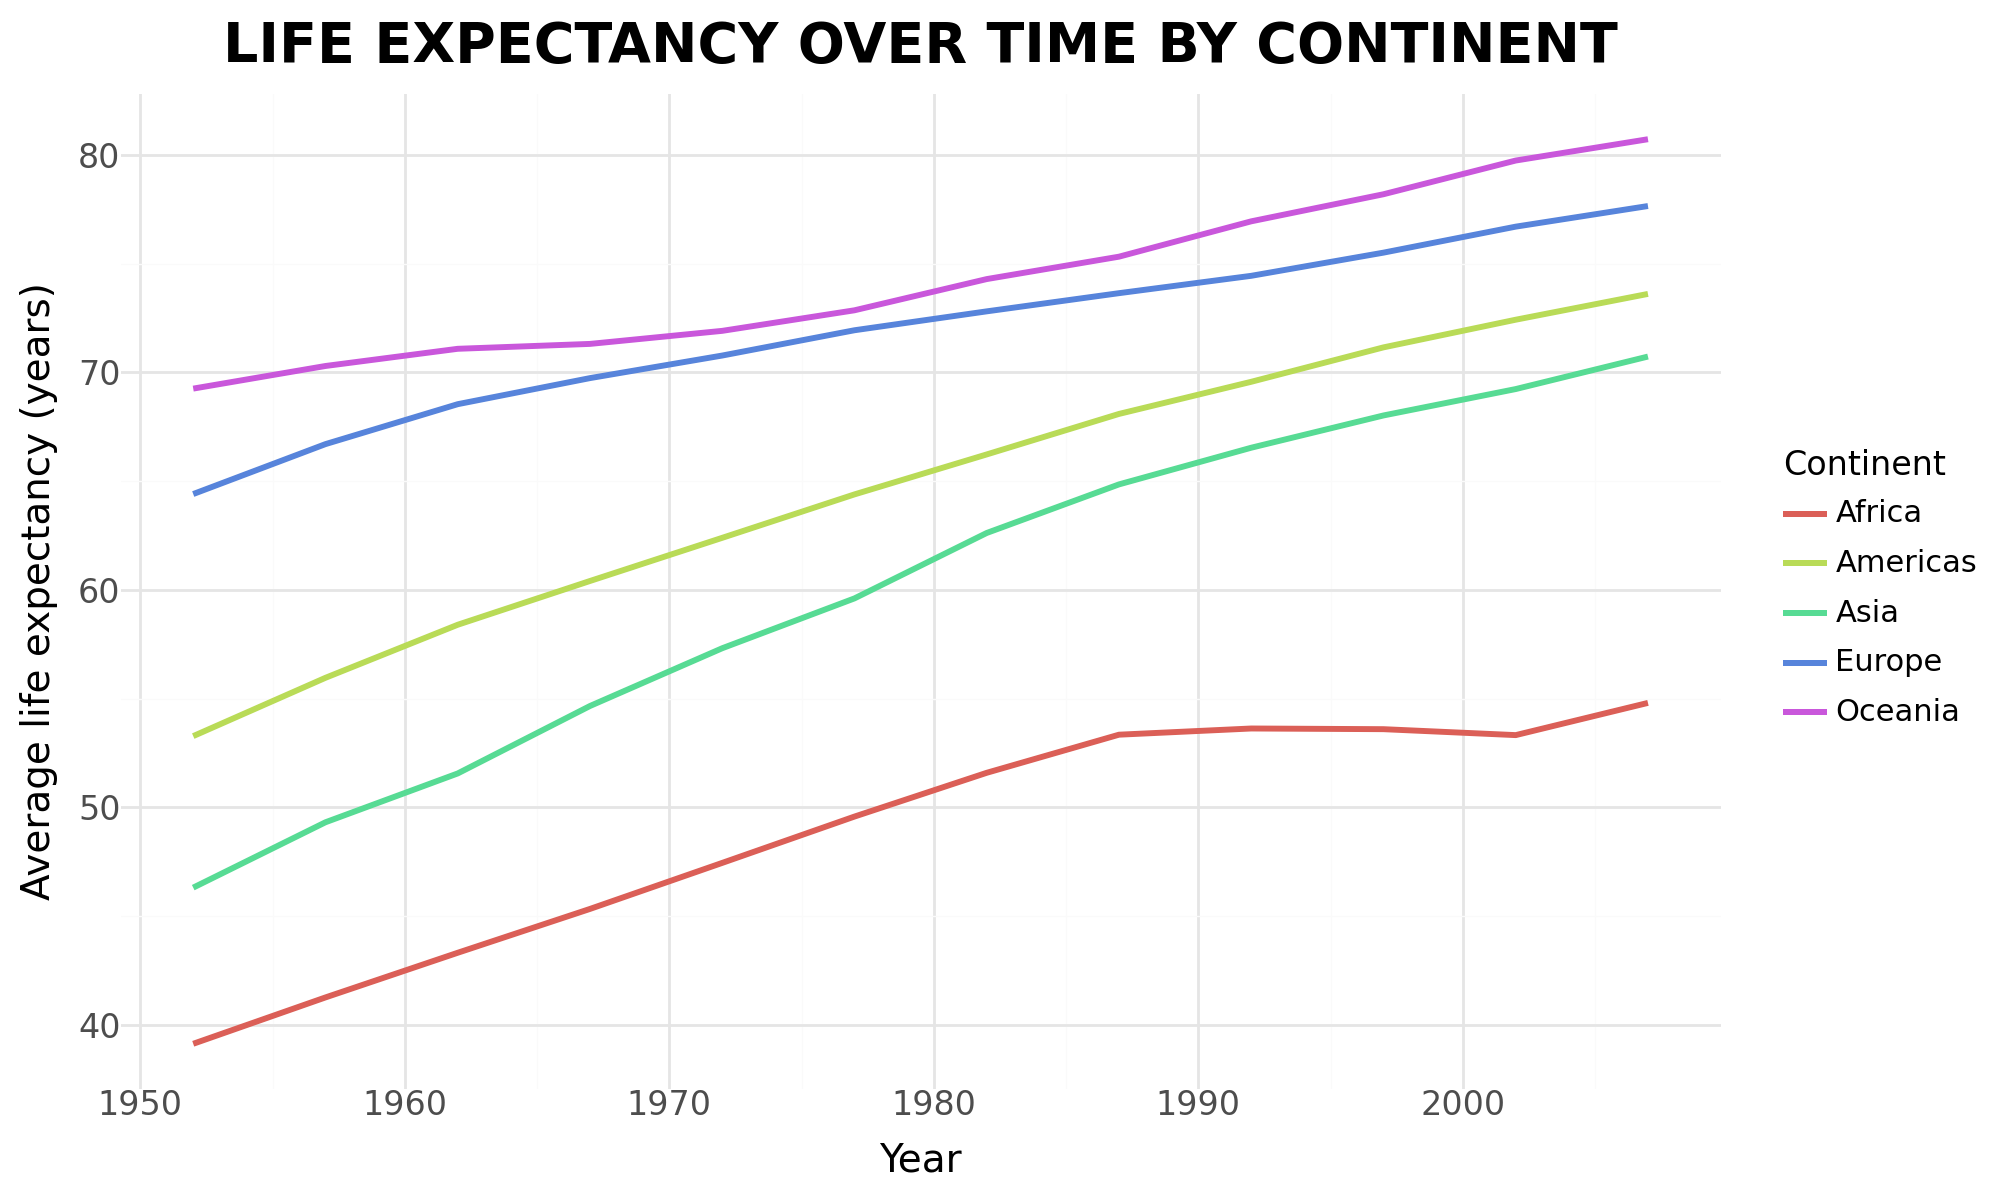

In [75]:
#| echo: false
#| warning: false
#| message: false
#| fig-width: 10
#| fig-height: 6
#| fig-cap: "Average life expectancy over time by continent (Gapminder)."

from plotnine import (
    ggplot, aes, geom_line, labs, theme_minimal, theme,
    element_text
)

(
    ggplot(
        gap_time_data,
        aes(
            x="year",
            y="avg_lifeExp",
            color="continent",
            group="continent"
        )
    )
    + geom_line(size=1.2)
    + labs(
        title="LIFE EXPECTANCY OVER TIME BY CONTINENT",
        x="Year",
        y="Average life expectancy (years)",
        color="Continent"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=20, weight="bold"),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=11)
    )
)

The continental trends are consistent with the distribution of <span style="color:#8c5a2b; font-weight:bold;">economic development</span>. <span style="color:#8c5a2b; font-weight:bold;">Europe</span> and <span style="color:#8c5a2b; font-weight:bold;">Oceania</span>, which represent the most developed regions, consistently show the highest levels of <span style="color:#8c5a2b; font-weight:bold;">life expectancy</span>, followed by the <span style="color:#8c5a2b; font-weight:bold;">Americas</span>. <span style="color:#8c5a2b; font-weight:bold;">Asia</span> occupies an intermediate position, while <span style="color:#8c5a2b; font-weight:bold;">Africa</span> remains at the lowest levels.

This pattern reinforces the idea that higher <span style="color:#8c5a2b; font-weight:bold;">development</span> is associated with longer life expectancy and a different structure of health risk across the life cycle.

### How does this pattern evolve over time?

To better understand whether this relationship is persistent, we examine how <span style="color:#8b1e1e; font-weight:bold;">early-life risk</span> evolves across different levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span> over time.

The time series chart shows that the gap between development levels remains remarkably stable: countries with higher <span style="color:#8c5a2b; font-weight:bold;">GDP</span> consistently display a higher relative concentration of <span style="color:#8b1e1e; font-weight:bold;">neonatal mortality</span>, while countries with lower <span style="color:#8c5a2b; font-weight:bold;">GDP</span> experience a more gradual transition.

This suggests that the shift toward <span style="color:#8b1e1e; font-weight:bold;">early-life risk</span> is not temporary, but a structural feature of <span style="color:#8c5a2b; font-weight:bold;">economic development</span>.

In [76]:
#| echo: false
#| warning: false
#| message: false
#| include: false

time_gdp_data = (
    data
    .with_columns([
        pl.col("year").cast(pl.Int64, strict=False),
        pl.col("GDP per capita").cast(pl.Float64, strict=False),
        pl.col("obs_value").cast(pl.Float64, strict=False)
    ])
    .filter(
        (pl.col("indicator") == "EARLY-LIFE RISK") &
        pl.col("year").is_not_null() &
        pl.col("GDP per capita").is_not_null() &
        pl.col("obs_value").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("GDP per capita") < 1135).then(pl.lit("Low income"))
        .when(pl.col("GDP per capita") < 4466).then(pl.lit("Lower middle"))
        .when(pl.col("GDP per capita") < 13846).then(pl.lit("Upper middle"))
        .otherwise(pl.lit("High income"))
        .alias("gdp_level")
    )
    .group_by(["year", "gdp_level"])
    .agg(
        pl.mean("obs_value").alias("avg_early_life_risk")
    )
    .sort(["gdp_level", "year"])
)

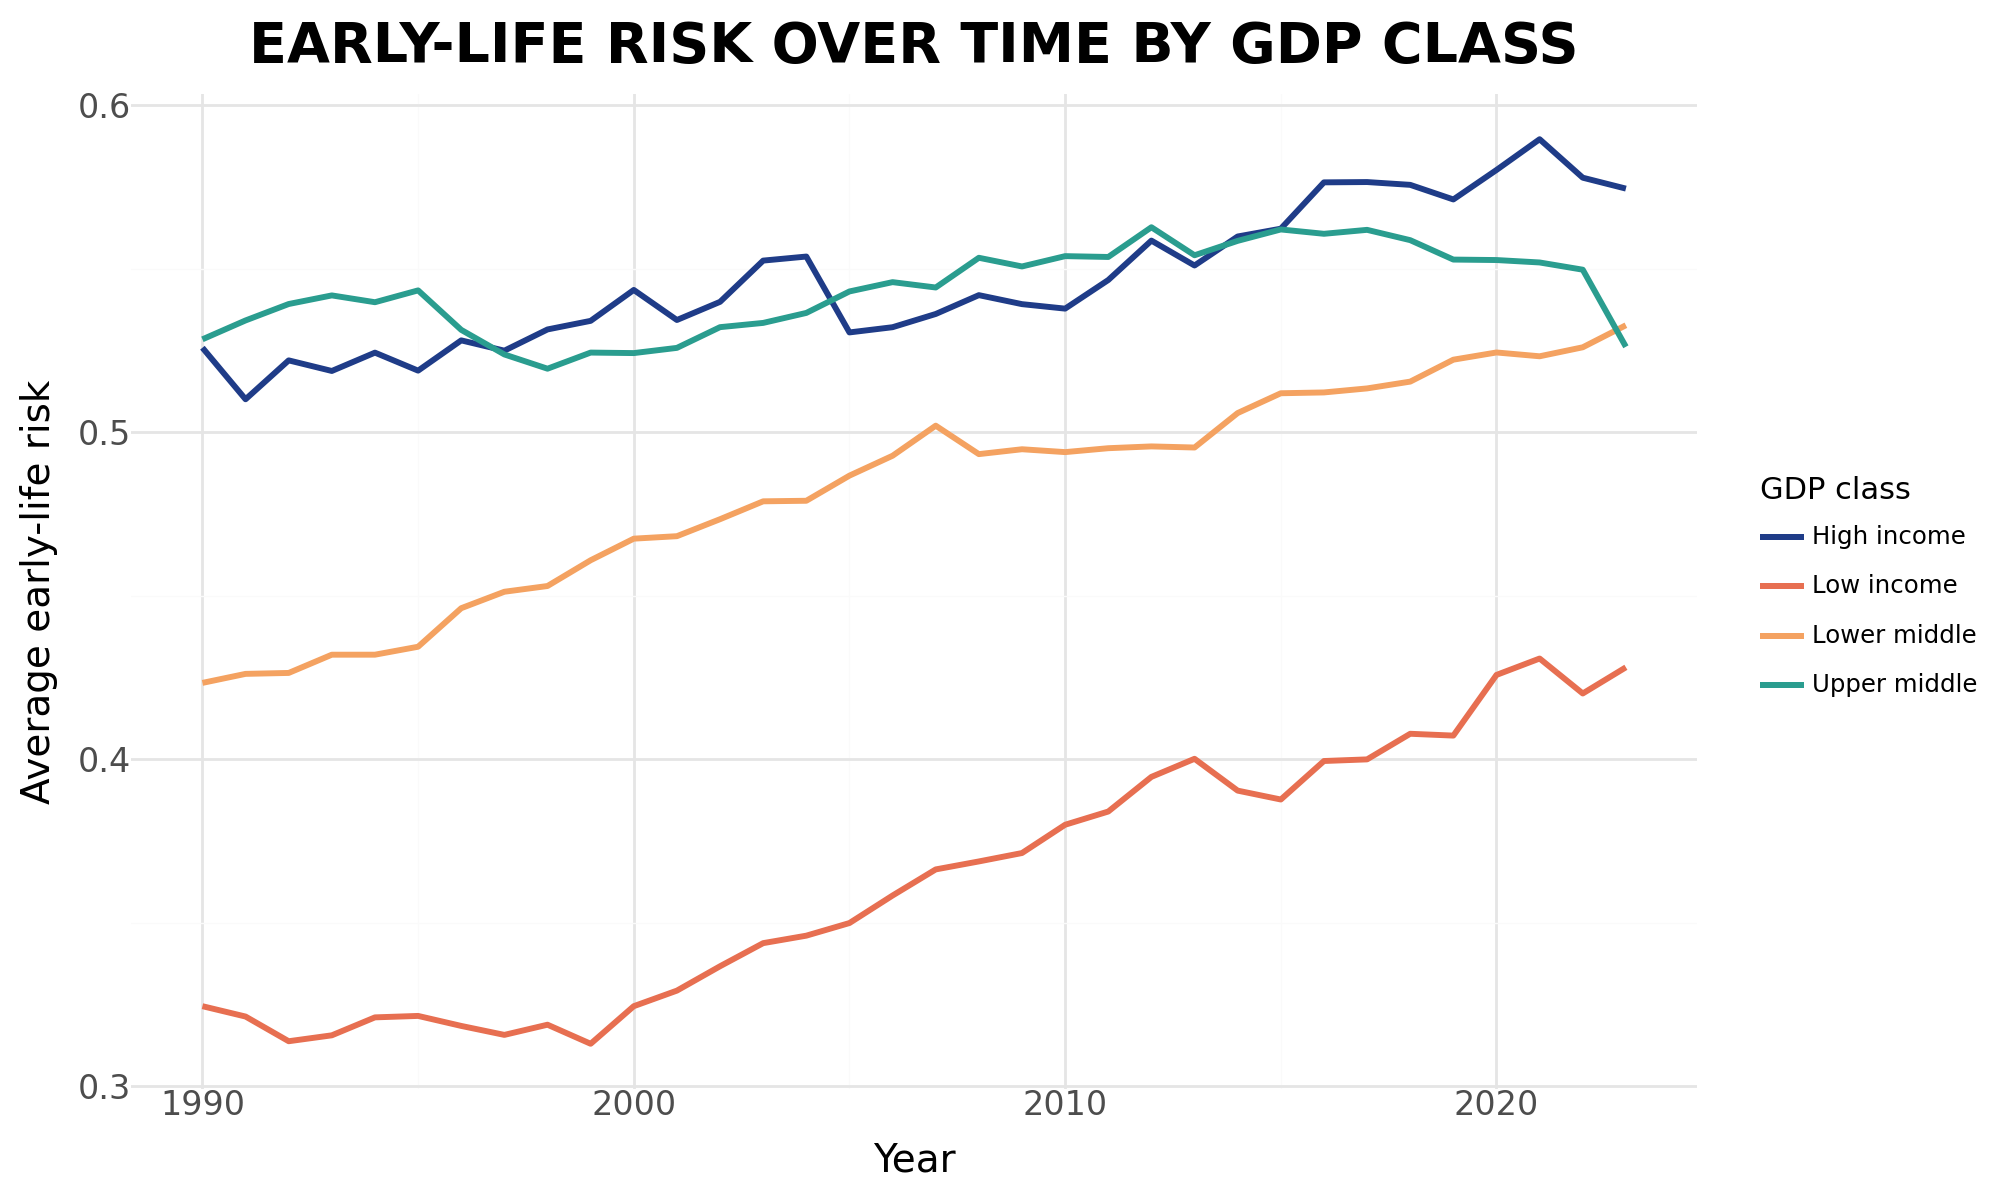

In [77]:
#| echo: false
#| warning: false
#| message: false
#| fig-width: 10
#| fig-height: 6
#| fig-cap: "Early-life risk over time by GDP class."

from plotnine import (
    ggplot, aes, geom_line, labs, theme_minimal, theme,
    element_text, scale_color_manual
)

gdp_colors = {
    "High income": "#1f3c88",
    "Upper middle": "#2a9d8f",
    "Lower middle": "#f4a261",
    "Low income": "#e76f51"
}

(
    ggplot(
        time_gdp_data,
        aes(
            x="year",
            y="avg_early_life_risk",
            color="gdp_level",
            group="gdp_level"
        )
    )
    + geom_line(size=1.2)
    + scale_color_manual(values=gdp_colors)
    + labs(
        title="EARLY-LIFE RISK OVER TIME BY GDP CLASS",
        x="Year",
        y="Average early-life risk",
        color="GDP class"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=20, weight="bold"),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12)
    )
)

Economic development does not eliminate risk — it reshapes it, concentrating mortality in earlier stages of life.

## From Early-Life Risk to Behavioural Risk

After the <span style="color:#8b1e1e; font-weight:bold;">early-life</span> phase, the nature of risk changes.

While <span style="color:#8b1e1e; font-weight:bold;">neonatal mortality</span> reflects biological constraints and the quality of healthcare systems, <span style="color:#1f3c88; font-weight:bold;">adolescence</span> introduces a different type of risk — one that is increasingly shaped by <span style="color:#1f3c88; font-weight:bold;">behaviour</span>, lifestyle and social environment.

In [78]:
gdp_colors = {
    "Low income": "#b0b0b0",
    "Lower middle": "#9ecae1",
    "Upper middle": "#3182bd",
    "High income": "#08306b"
}

In [79]:
#| echo: false
#| warning: false
#| message: false
#| include: false

scatter_data = (
    data
    .with_columns([
        pl.col("GDP per capita").cast(pl.Float64, strict=False),
        pl.col("obs_value").cast(pl.Float64, strict=False),
        pl.col("year").cast(pl.Int64, strict=False)
    ])
    .filter(
        (pl.col("year") == 2016) &
        (pl.col("sex") == "Total") &
        (pl.col("indicator") == "BEHAVIOURAL RISK") &
        pl.col("GDP per capita").is_not_null() &
        pl.col("obs_value").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("GDP per capita") < 1135).then(pl.lit("Low income"))
        .when(pl.col("GDP per capita") < 4466).then(pl.lit("Lower middle"))
        .when(pl.col("GDP per capita") < 13846).then(pl.lit("Upper middle"))
        .otherwise(pl.lit("High income"))
        .alias("gdp_level")
    )
    .select([
        "country",
        "GDP per capita",
        "obs_value",
        "gdp_level"
    ])
)

In [80]:
#| echo: false
#| warning: false
#| message: false
#| include: false

normalized_comparison_data = (
    data
    .with_columns([
        pl.col("GDP per capita").cast(pl.Float64, strict=False),
        pl.col("obs_value").cast(pl.Float64, strict=False),
        pl.col("year").cast(pl.Int64, strict=False)
    ])
    .filter(
        (pl.col("year") == 2016) &
        (pl.col("sex") == "Total") &
        pl.col("GDP per capita").is_not_null() &
        pl.col("obs_value").is_not_null() &
        pl.col("indicator").is_in([
            "BEHAVIOURAL RISK",
            "EARLY-LIFE RISK"
        ])
    )
    .with_columns(
        pl.when(pl.col("GDP per capita") < 1135).then(pl.lit("Low income"))
        .when(pl.col("GDP per capita") < 4466).then(pl.lit("Lower middle"))
        .when(pl.col("GDP per capita") < 13846).then(pl.lit("Upper middle"))
        .otherwise(pl.lit("High income"))
        .alias("gdp_level")
    )
    .group_by(["gdp_level", "indicator"])
    .agg(
        pl.mean("obs_value").alias("avg_risk")
    )
)

risk_max = (
    normalized_comparison_data
    .group_by("indicator")
    .agg(
        pl.max("avg_risk").alias("max_risk")
    )
)

normalized_comparison_data = (
    normalized_comparison_data
    .join(risk_max, on="indicator", how="left")
    .with_columns(
        (pl.col("avg_risk") / pl.col("max_risk")).alias("normalized_risk")
    )
    .select(["gdp_level", "indicator", "normalized_risk"])
)

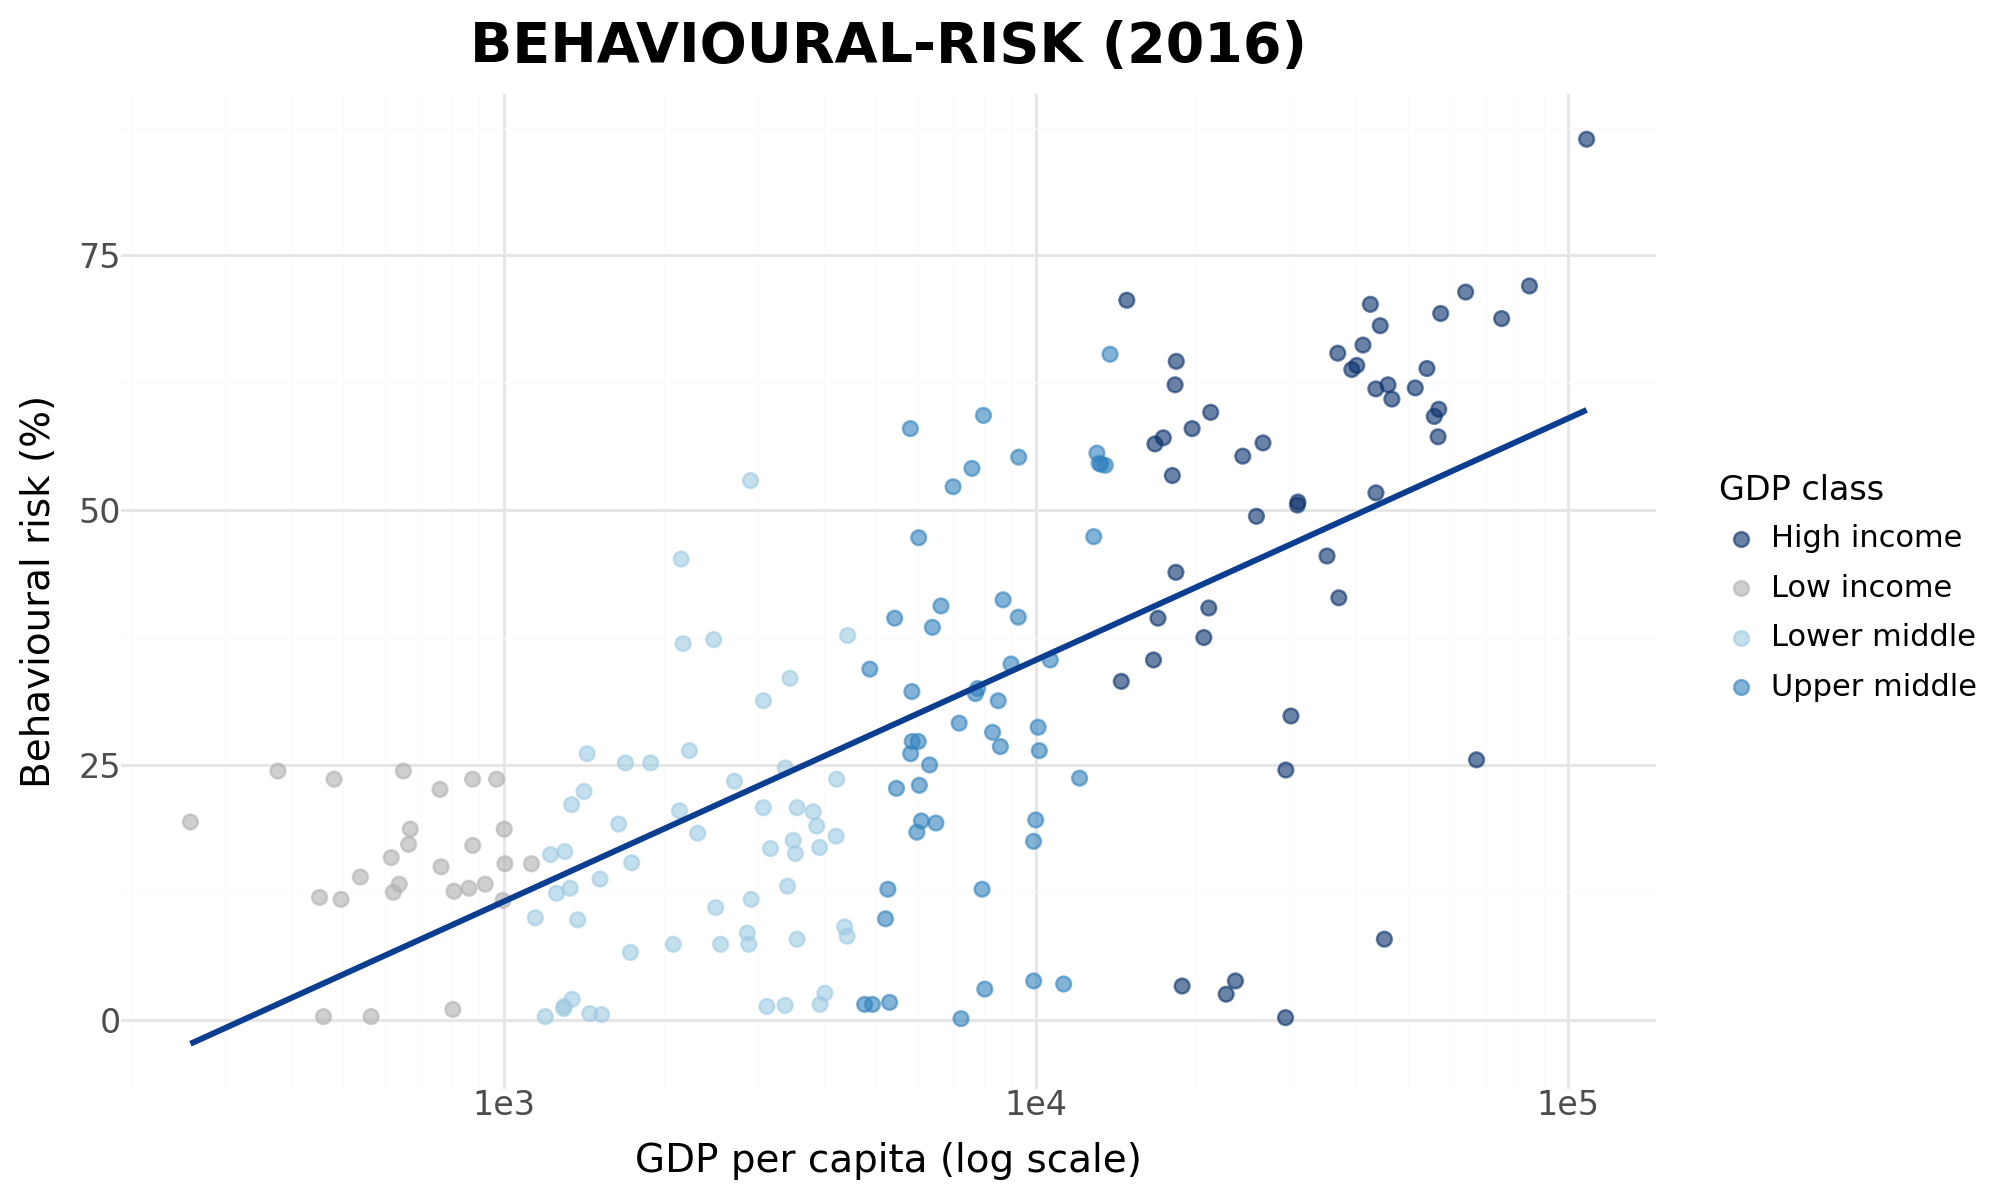

In [81]:
#| echo: false
#| warning: false
#| message: false
#| fig-width: 10
#| fig-height: 6
#| fig-cap: "Relationship between GDP per capita and behavioural risk by income level (2016)."

from plotnine import (
    ggplot, aes, geom_point, geom_smooth,
    scale_x_log10, labs, theme_minimal, theme,
    element_text, scale_color_manual
)

gdp_colors = {
    "Low income": "#b0b0b0",
    "Lower middle": "#9ecae1",
    "Upper middle": "#3182bd",
    "High income": "#08306b"
}

(
    ggplot(
        scatter_data,
        aes(
            x="GDP per capita",
            y="obs_value",
            color="gdp_level"
        )
    )
    + geom_point(alpha=0.6, size=2.5)
    + geom_smooth(method="lm", se=False, color="#0B3D91", size=1.2)
    + scale_color_manual(values=gdp_colors)
    + scale_x_log10()
    + labs(
        title="BEHAVIOURAL-RISK (2016)",
        x="GDP per capita (log scale)",
        y="Behavioural risk (%)",
        color="GDP class"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=20, weight="bold"),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=11)
    )
)

### Alcohol Consumption and economic development

The scatterplot reveals a clear pattern: countries with higher levels of <span style="color:#8c5a2b; font-weight:bold;">GDP per capita</span> tend to exhibit higher levels of <span style="color:#1f3c88; font-weight:bold;">adolescent behavioural risk</span>.

This does not imply that countries with higher <span style="color:#8c5a2b; font-weight:bold;">GDP</span> are “less healthy”. Rather, it indicates that risk takes a different form. As survival improves and basic health threats decline, new risks emerge, often linked to lifestyle choices such as <span style="color:#1f3c88; font-weight:bold;">alcohol consumption</span>.

In this phase, <span style="color:#8c5a2b; font-weight:bold;">economic development</span> expands opportunities, exposure and autonomy, particularly among younger populations, increasing the likelihood of engaging in <span style="color:#1f3c88; font-weight:bold;">risky behaviours</span>.

## Is Risk Reduced or Redistributed?

The comparison between <span style="color:#8b1e1e; font-weight:bold;">early-life risk</span> and <span style="color:#1f3c88; font-weight:bold;">behavioural risk</span> highlights a fundamental shift in the structure of health risk.

- In countries with lower levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span>, risk is primarily concentrated in survival-related conditions during <span style="color:#8b1e1e; font-weight:bold;">early life</span>.  
- In countries with higher levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span>, risk progressively shifts toward <span style="color:#1f3c88; font-weight:bold;">behavioural factors</span> during <span style="color:#1f3c88; font-weight:bold;">adolescence</span>.


::: {.callout-important}
As countries develop, risk extends itself according to the perceived level of safety within a country, which is indirectly related to their GDP and, consequently, to their structural development, including both urbanization and exposure to well-organized healthcare infrastructures. In more developed contexts, this creates a dual effect: on one hand, better healthcare systems lead to a higher concentration of neonatal mortality, as deaths become less related to preventable conditions and more linked to structural and biological factors; on the other hand, increased safety and stability reduce the perceived danger of everyday life, making individuals, especially in urban environments, more willing to expose themselves to new forms of risk.
:::

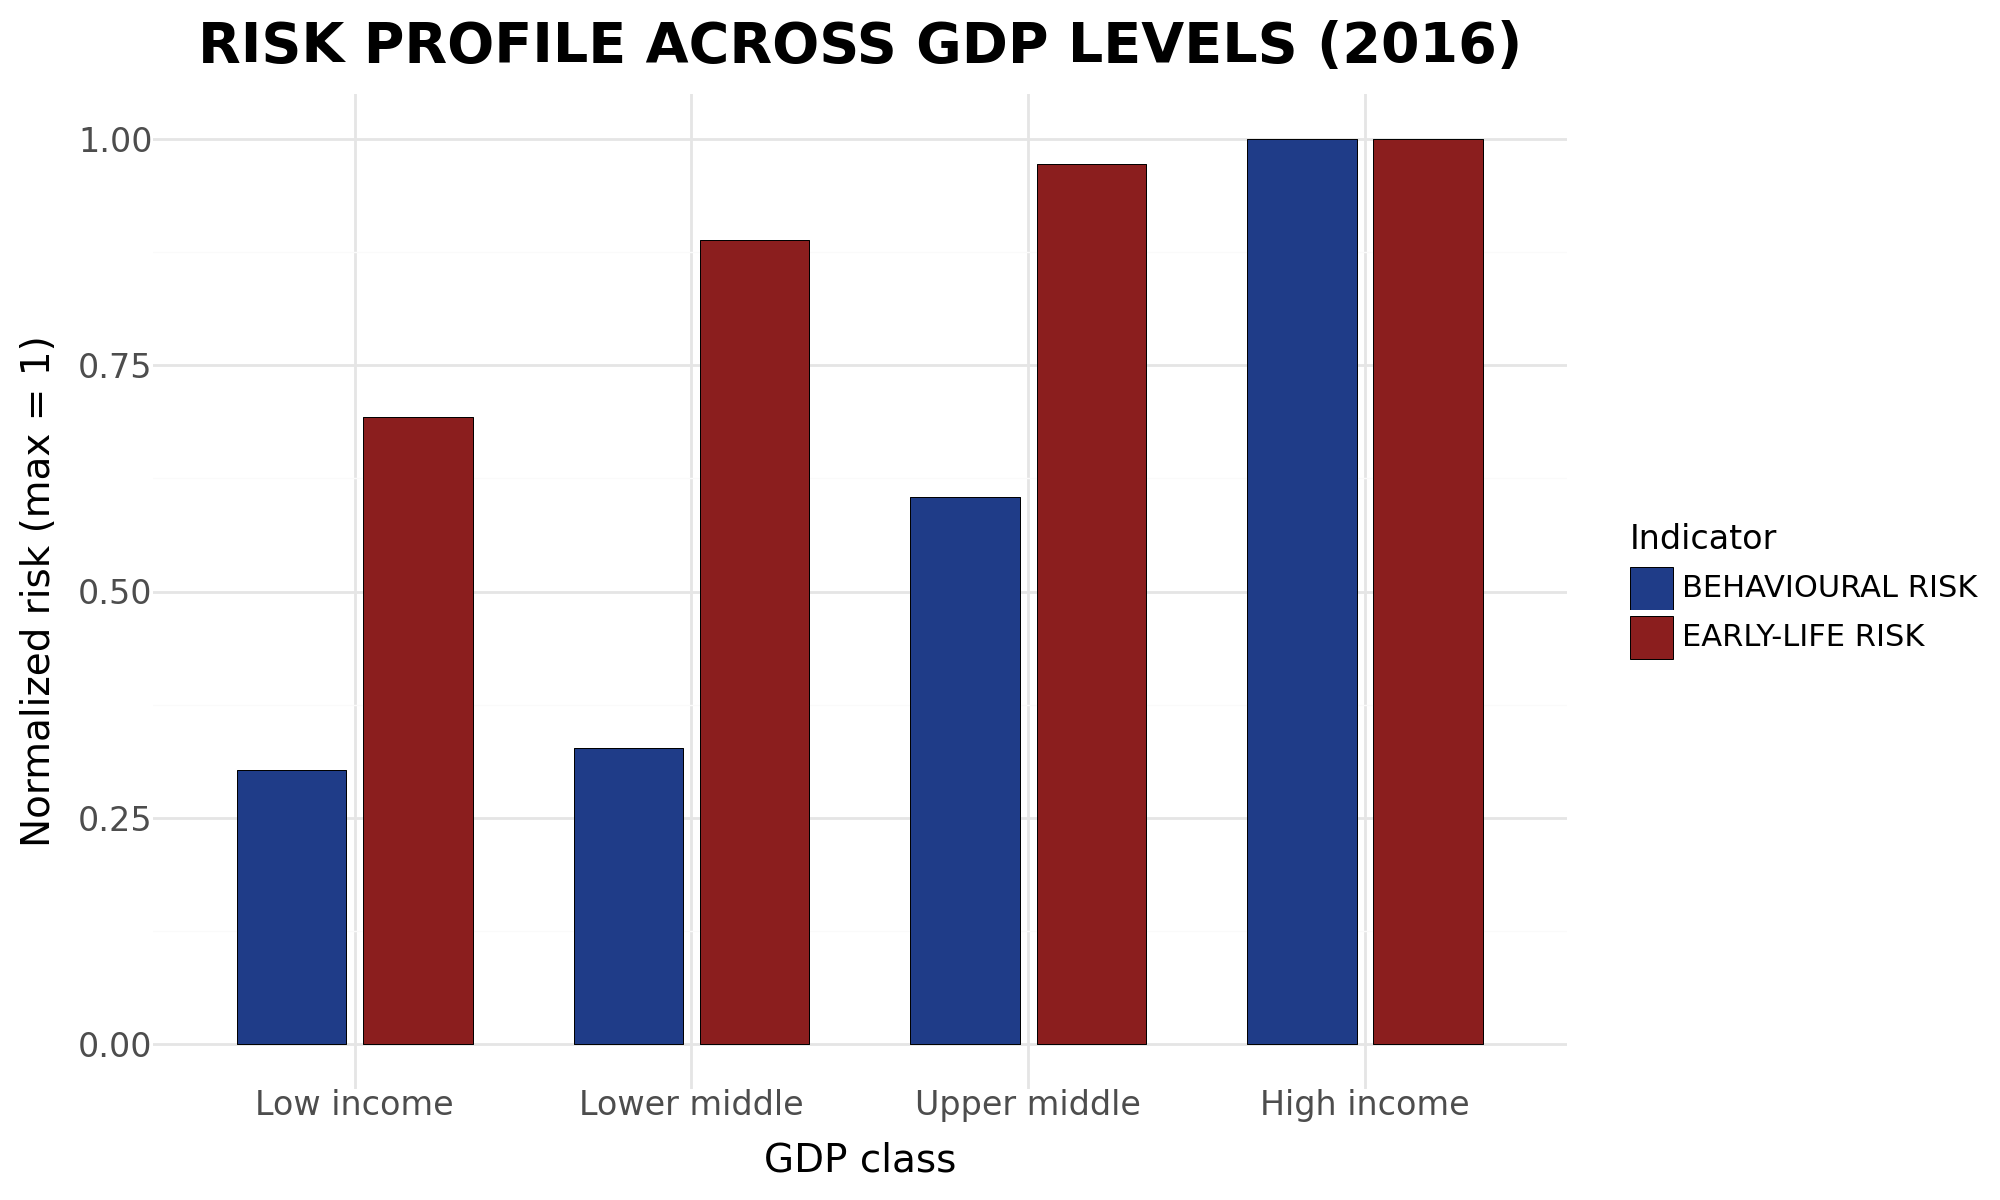

In [82]:
#| echo: false
#| warning: false
#| message: false
#| fig-width: 10
#| fig-height: 6
#| fig-cap: "Normalized comparison of early-life and behavioural risk across GDP classes (2016)."

from plotnine import (
    ggplot, aes, geom_col, labs,
    theme_minimal, theme, element_text,
    scale_fill_manual, position_dodge, scale_x_discrete
)

gdp_order = ["Low income", "Lower middle", "Upper middle", "High income"]

(
    ggplot(
        normalized_comparison_data,
        aes(x="gdp_level", y="normalized_risk", fill="indicator")
    )
    + geom_col(
        position=position_dodge(width=0.75),
        width=0.65,
        color="black",
        size=0.2
    )
    + scale_x_discrete(limits=gdp_order)
    + scale_fill_manual(values={
        "BEHAVIOURAL RISK": "#1f3c88",
        "EARLY-LIFE RISK": "#8b1e1e"
    })
    + labs(
        title="RISK PROFILE ACROSS GDP LEVELS (2016)",
        x="GDP class",
        y="Normalized risk (max = 1)",
        fill="Indicator"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=20, weight="bold"),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=11)
    )
)

### A normalized comparison

By normalizing both indicators, we can directly compare how risk is distributed across different levels of <span style="color:#8c5a2b; font-weight:bold;">GDP</span>.



- <span style="color:#8b1e1e; font-weight:bold;">Early-life risk</span> remains relatively high across all countries, reflecting structural constraints that are harder to eliminate even at higher levels of <span style="color:#8c5a2b; font-weight:bold;">development</span>.  
- <span style="color:#1f3c88; font-weight:bold;">Behavioural risk</span> increases sharply with <span style="color:#8c5a2b; font-weight:bold;">GDP</span>, becoming more prominent in high-<span style="color:#8c5a2b; font-weight:bold;">GDP</span> settings.

::: {.callout-note}
A key implication of this report is that public health progress should not be interpreted as the **end of risk**, but as a **shift in where risk is located across the life cycle**.
:::

## Key findings

1. <span style="color:#8b1e1e; font-weight:bold;">Early-Life Risk</span> is higher in countries with higher levels of <span style="color:#8c5a2b; font-weight:bold;">development</span>, and this should be interpreted positively, as it indicates a structural and medical limit that cannot be significantly reduced through further improvements in healthcare systems. It represents a type of risk that is almost irreducible.

2. The type of risk during the life cycle shifts from survival-related risk to <span style="color:#1f3c88; font-weight:bold;">Behavioural Risk</span>, and the urbanization of a country, and therefore its level of <span style="color:#8c5a2b; font-weight:bold;">GDP</span>, actively influences the stimuli perceived by <span style="color:#1f3c88; font-weight:bold;">adolescents</span>. Adolescents in more urbanized and developed countries are therefore more likely to engage in <span style="color:#1f3c88; font-weight:bold;">alcohol consumption</span>, increasing <span style="color:#1f3c88; font-weight:bold;">behavioural risk</span> during adolescence.

### <span style="color:#8c5a2b; font-weight:bold;">High-income countries consistently appear at the top of the distribution</span>

Overall, the analysis suggests that <span style="color:#8c5a2b; font-weight:bold;">economic development</span> does not simply reduce risk, but changes how risk is distributed across the life course. In more developed countries, some risks that are less immediate, such as <span style="color:#1f3c88; font-weight:bold;">risky behaviours</span> during adolescence, may receive less attention in the short term but can become significant over time.

In contrast, in less developed countries, where <span style="color:#8b1e1e; font-weight:bold;">early-life mortality risk</span> is already high, populations and systems tend to avoid additional risks, as everyday life is already characterized by higher baseline danger. This suggests that differences in risk behaviour are not only a consequence of <span style="color:#8c5a2b; font-weight:bold;">development</span>, but also a form of adaptation to the surrounding risk environment.





### Final Insight

Health risk is not a fixed quantity, it evolves with <span style="color:#8c5a2b; font-weight:bold;">development</span>.

From <span style="color:#8b1e1e; font-weight:bold;">early-life</span> survival challenges to <span style="color:#1f3c88; font-weight:bold;">behavioural risks</span> in <span style="color:#1f3c88; font-weight:bold;">adolescence</span>, the life cycle of risk mirrors the broader process of <span style="color:#8c5a2b; font-weight:bold;">economic</span> and social transformation.

## Reproducibility
### Code
The full code used for data preparation, analysis and visualisation is available on GitHub:

[View the notebook]()

### Data
[Dataset 1 - Neonatal deaths as a percentage of under-five deaths](https://github.com/sabrinavitali/economic-development-health-risk/blob/main/unicef_indicator_1.csv)

[Dataset 2 - Percentage of adolescents (aged 15-19 years) who had at least one alcoholic drink at any time during the last 12 months](https://github.com/sabrinavitali/economic-development-health-risk/blob/main/unicef_indicator_2.csv)

[Dataset 3 - UNICEF metadata](https://github.com/sabrinavitali/economic-development-health-risk/blob/main/unicef_metadata.csv)

In [83]:
#| include: false
!pip install quarto-cli

In [84]:
#| include: false
!quarto render "/content/drive/MyDrive/Colab Notebooks/index.ipynb"

pandoc 
  to: html
  output-file: index.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  toc: true
  toc-depth: 2
  number-sections: true
  variables: {}
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  engines:
    - path: /usr/local/lib/python3.12/dist-packages/quarto_cli/share/extension-subtrees/julia-engine/_extensions/julia-engine/julia-engine.js
  title: How Economic Development Reshapes Health Risk Across the Life Cycle
  subtitle: How two distinct risk indicators evolve with economic development
  date: '2026-04-10'
  author: Sabrina Vitali
  fontsize: 1.1em
  linestretch: 1.7
  theme: flatly
  
Output created: index.html

